In [15]:
import gmsh
import ufl
import numpy as np
import matplotlib.pyplot as plt

from mpi4py import MPI
from dolfinx import fem
from pathlib import Path
from airflow_estimator import AirflowEstimator, Visualizer2D


Info    : Reading '../meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 835 nodes
Info    : 1678 elements
Info    : Done reading '../meshes/rectangle_circular_holes/mesh.msh'


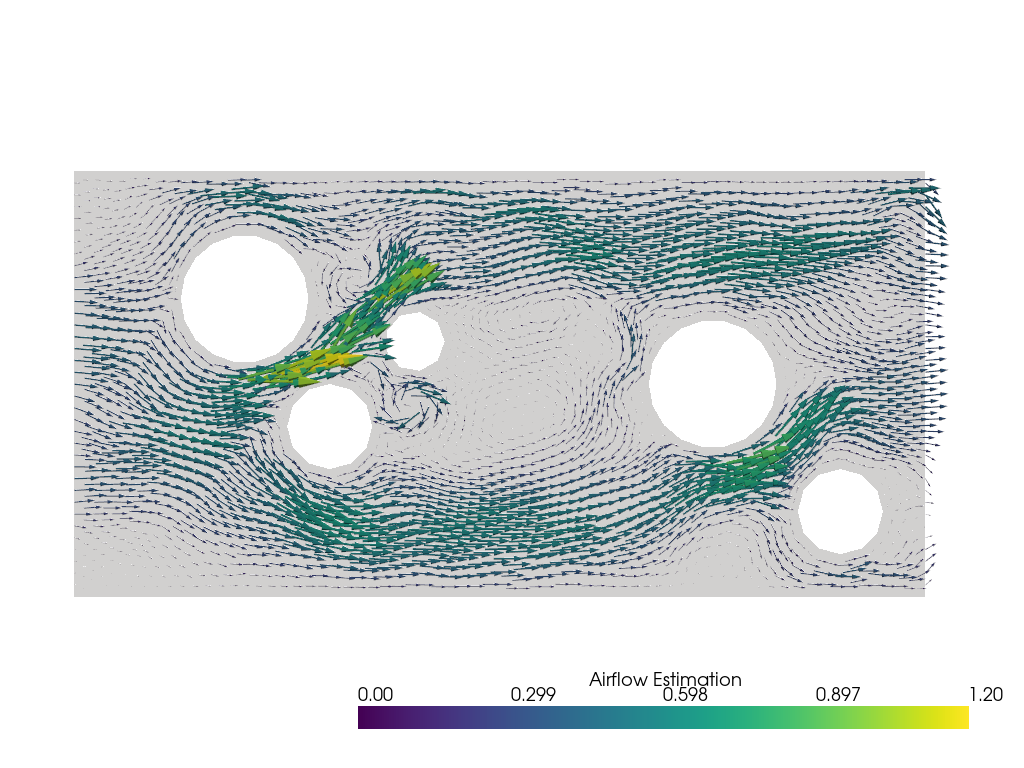

In [ ]:
# Example usage 
meshfile = Path("../meshes/rectangle_circular_holes/mesh.msh")
bpfile   = Path("../wind_data/airflow_picard.bp")

est = AirflowEstimator.from_file(bpfile, fun_name="velocity_H2", meshtags_name="facet_tags", p=50)
est.set_weights(kin_v=1.5e-4, misfit=1e0, pde_err=1e3, reg=1e-3)

# Boundary conditions
V = est.V
Q = est.Q
W0 = est.W0
W1 = est.W1
W = est.W

gmsh.initialize()
gmsh.open(str(meshfile))
phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {gmsh.model.getPhysicalName(dim, tag): tag for (dim, tag) in phy_groups}
gmsh.finalize()

facet_tags = est.facet_tags

# No slip boundary condition
u_D_no_slip = fem.Function(V)
u_D_no_slip.x.array[:] = 0.0
no_slip_names = ["Walls", "Obstacles"]
dofs_local = np.concatenate([facet_tags.find(name_to_id[name]) for name in no_slip_names])
dofs_no_slip = fem.locate_dofs_topological((W0, V), V.mesh.topology.dim - 1, dofs_local)

bc_no_slip = fem.dirichletbc(u_D_no_slip, dofs_no_slip, W0)

# Outflow - zero pressure
p_zero = fem.Function(Q)
p_zero.x.array[:] = 0.0
p_1_facets = ["Outflow"]
dofs_local = np.concatenate([facet_tags.find(name_to_id[name]) for name in p_1_facets])
dofs_out = fem.locate_dofs_topological((W1, Q), V.mesh.topology.dim - 1, dofs_local)

bc_out = fem.dirichletbc(p_zero, dofs_out, W1)

In [10]:
def l2_component_errors(u_true: fem.Function, u_est: fem.Function):
    """
    L2-Norm pro Komponente: Ex = ||(u_est - u_true)_x||_L2, Ey analog.
    Beide Felder müssen im gleichen Vektorraum liegen.
    """
    V = u_true.function_space
    diff = fem.Function(V)
    diff.x.array[:] = (u_est.x.array - u_true.x.array)

    ex = ufl.dot(diff, ufl.as_vector((1.0, 0.0)))
    ey = ufl.dot(diff, ufl.as_vector((0.0, 1.0)))

    Ex = fem.assemble_scalar(fem.form(ex*ex * ufl.dx))**0.5
    Ey = fem.assemble_scalar(fem.form(ey*ey * ufl.dx))**0.5

    return Ex, Ey



def tune_alpha_beta(
                    alphas=np.logspace(-3, 5, 9),
                    betas =np.logspace(-3, 5, 9),
                    gamma_fixed=1e-3,
                    solve_kwargs=None):

    if solve_kwargs is None:
        solve_kwargs = dict(maxit=3, tol=1e-2)

    A = np.asarray(alphas, dtype=float)
    B = np.asarray(betas, dtype=float)
    ExM = np.full((len(A), len(B)), np.nan)
    EyM = np.full_like(ExM, np.nan)
    EM  = np.full_like(ExM, np.nan)

    for ia, alpha in enumerate(A):
        for ib, beta in enumerate(B):
            try:
                est = AirflowEstimator.from_file(bpfile, fun_name="velocity_H2", meshtags_name="facet_tags", p=50, seed=1)
                u_true = est.ground_truth.sub(0).collapse()
                est.add_dirichlet_bc([bc_no_slip, bc_out])
                est.set_weights(kin_v=None, misfit=alpha, pde_err=beta, reg=gamma_fixed)
                result = est.solve(**solve_kwargs)
                u_est = result.sub(0).collapse()

                Ex, Ey = l2_component_errors(u_true, u_est)
                ExM[ia, ib] = Ex
                EyM[ia, ib] = Ey
                EM[ia, ib]  = Ex + Ey

            except Exception as e:
                print(f"[α={alpha:.2e}, β={beta:.2e}] failed: {e}")
                continue

    # Bestes Paar
    valid_mask = np.isfinite(EM)
    if not np.any(valid_mask):
        raise RuntimeError("All tuning runs failed; no finite error values were produced.")

    # Maske ungültige Einträge aus
    EM_valid = np.copy(EM)
    EM_valid[~valid_mask] = np.inf

    ia_best, ib_best = np.unravel_index(np.argmin(EM_valid), EM_valid.shape)
    best = {
        "alpha": A[ia_best],
        "beta":  B[ib_best],
        "gamma": gamma_fixed,
        "Ex":    ExM[ia_best, ib_best],
        "Ey":    EyM[ia_best, ib_best],
        "E":     EM[ia_best, ib_best],
        "ia": ia_best,
        "ib": ib_best,
    }

    return A, B, EM, ExM, EyM, best

def tune_alpha_beta_avg(
        alphas=np.logspace(-3, 5, 9),
        betas=np.logspace(-3, 5, 9),
        gamma_fixed=1e-3,
        seeds=range(1, 11),
        solve_kwargs=None):

    A = np.asarray(alphas, dtype=float)
    B = np.asarray(betas, dtype=float)

    # Akkumulatoren für Mittelung
    ExM_acc = np.zeros((len(A), len(B)))
    EyM_acc = np.zeros_like(ExM_acc)
    EM_acc  = np.zeros_like(ExM_acc)
    count   = np.zeros_like(ExM_acc)

    for seed in seeds:
        print(f"\n=== Running seed {seed} ===")
        A, B, EM, ExM, EyM, best = tune_alpha_beta(
            alphas=alphas, betas=betas, gamma_fixed=gamma_fixed,
            solve_kwargs=solve_kwargs)

        # Akkumulieren (nur gültige Werte)
        mask = np.isfinite(EM)
        ExM_acc[mask] += ExM[mask]
        EyM_acc[mask] += EyM[mask]
        EM_acc[mask]  += EM[mask]
        count[mask]   += 1

    # Mittelwert über Seeds bilden
    valid = count > 0
    ExM_mean = np.full_like(ExM_acc, np.nan)
    EyM_mean = np.full_like(EyM_acc, np.nan)
    EM_mean  = np.full_like(EM_acc, np.nan)

    ExM_mean[valid] = ExM_acc[valid] / count[valid]
    EyM_mean[valid] = EyM_acc[valid] / count[valid]
    EM_mean[valid]  = EM_acc[valid] / count[valid]

    # Bestes Paar über den gemittelten Fehlern
    ia_best, ib_best = np.unravel_index(np.nanargmin(EM_mean), EM_mean.shape)
    best_mean = {
        "alpha": A[ia_best],
        "beta":  B[ib_best],
        "gamma": gamma_fixed,
        "Ex":    ExM_mean[ia_best, ib_best],
        "Ey":    EyM_mean[ia_best, ib_best],
        "E":     EM_mean[ia_best, ib_best],
        "ia": ia_best, "ib": ib_best
    }

    return A, B, EM_mean, ExM_mean, EyM_mean, best_mean


def make_log_edges(vals):
    """Compute cell edges from log-spaced centers for pcolormesh."""
    r = vals[1] / vals[0]
    edges = np.concatenate(([vals[0] / np.sqrt(r)],
                            np.sqrt(vals[:-1] * vals[1:]),
                            [vals[-1] * np.sqrt(r)]))
    return edges


def plot_tuning(A, B, EM, ExM, EyM, best, title="Hyperparameter sweep"):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    titles = [r"$E = E_x + E_y$", r"$E_x$ (L2)", r"$E_y$ (L2)"]
    data   = [EM, ExM, EyM]

    A_edges = make_log_edges(A)
    B_edges = make_log_edges(B)

    for ax, D, subtitle in zip(axs, data, titles):
        D = np.array(D, dtype=float)
        D[~np.isfinite(D)] = np.nan

        pcm = ax.pcolormesh(A_edges, B_edges, D.T, shading="auto", cmap="viridis")
        fig.colorbar(pcm, ax=ax, label="L2 error")

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"$\alpha$ (misfit)")
        ax.set_ylabel(r"$\beta$ (PDE)")
        ax.set_title(subtitle)

        ax.scatter(best["alpha"], best["beta"], color="magenta", marker="o", label="best", zorder=5)
        ax.legend()

    # --- globaler Titel ---
    fig.suptitle(title, fontsize=16, y=1.05)

    plt.tight_layout()
    plt.show()


=== Running seed 1 ===

=== Running seed 2 ===

=== Running seed 3 ===

=== Running seed 4 ===

=== Running seed 5 ===

=== Running seed 6 ===

=== Running seed 7 ===

=== Running seed 8 ===

=== Running seed 9 ===

=== Running seed 10 ===


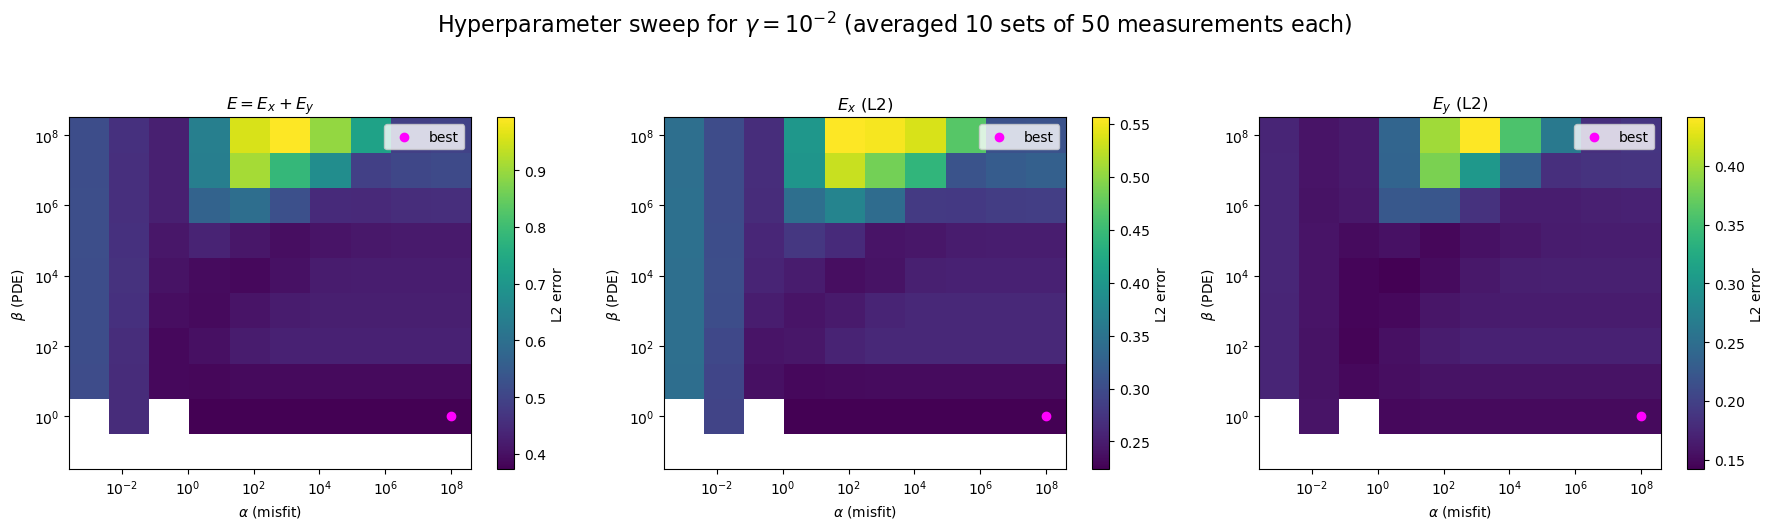

In [11]:
# Set ranges
alphas = np.logspace(-3, 8, 10)
betas  = np.logspace(-1, 8, 10)
gamma  = 1e-2


A, B, EM, ExM, EyM, best = tune_alpha_beta_avg(
    alphas=alphas, betas=betas, gamma_fixed=gamma,
    seeds=range(1, 11), 
    solve_kwargs=dict(maxit=3, tol=1e-4)
)

plot_tuning(A, B, EM, ExM, EyM, best, title=r"Hyperparameter sweep for $\gamma = 10^{-2}$ (averaged 10 sets of 50 measurements each)")


=== Running seed 1 ===

=== Running seed 2 ===

=== Running seed 3 ===

=== Running seed 4 ===

=== Running seed 5 ===

=== Running seed 6 ===

=== Running seed 7 ===

=== Running seed 8 ===

=== Running seed 9 ===

=== Running seed 10 ===


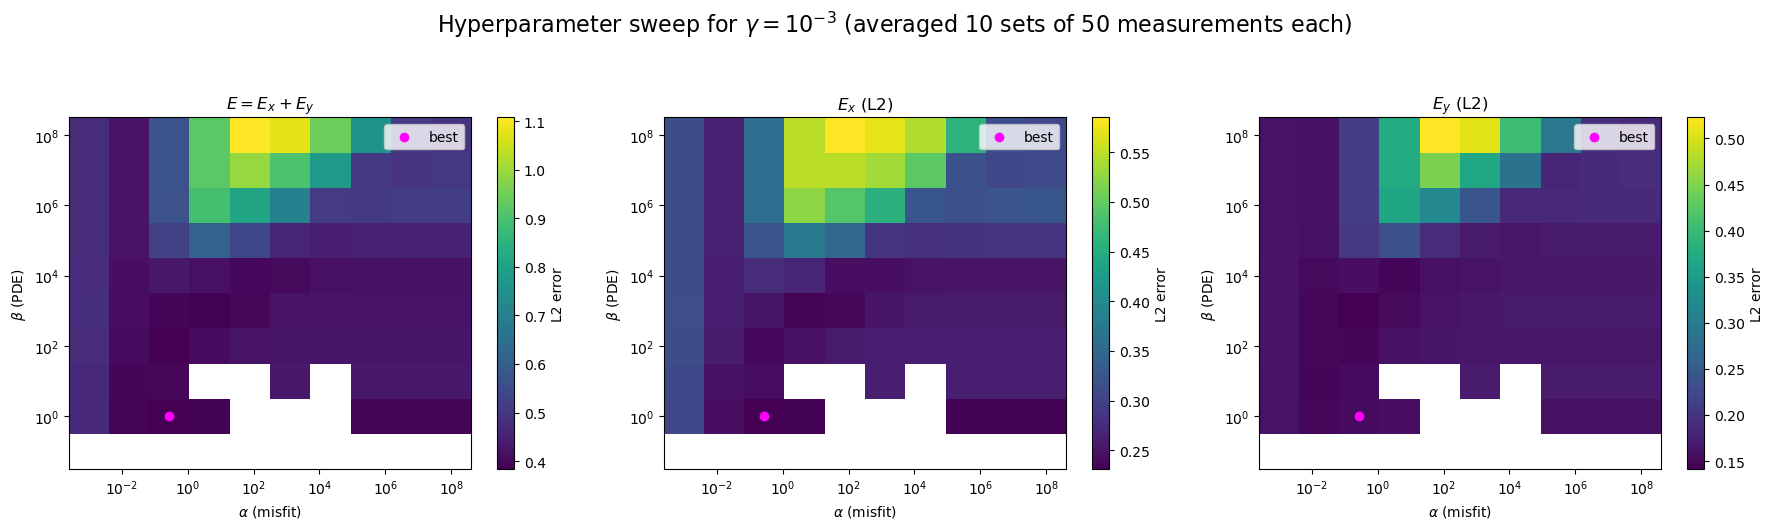

In [12]:
# Set ranges
alphas = np.logspace(-3, 8, 10)
betas  = np.logspace(-1, 8, 10)
gamma  = 1e-3


A, B, EM, ExM, EyM, best = tune_alpha_beta_avg(
    alphas=alphas, betas=betas, gamma_fixed=gamma,
    seeds=range(1, 11), 
    solve_kwargs=dict(maxit=3, tol=1e-4)
)

plot_tuning(A, B, EM, ExM, EyM, best, title=r"Hyperparameter sweep for $\gamma = 10^{-3}$ (averaged 10 sets of 50 measurements each)")


=== Running seed 1 ===

=== Running seed 2 ===

=== Running seed 3 ===

=== Running seed 4 ===

=== Running seed 5 ===

=== Running seed 6 ===

=== Running seed 7 ===

=== Running seed 8 ===

=== Running seed 9 ===

=== Running seed 10 ===


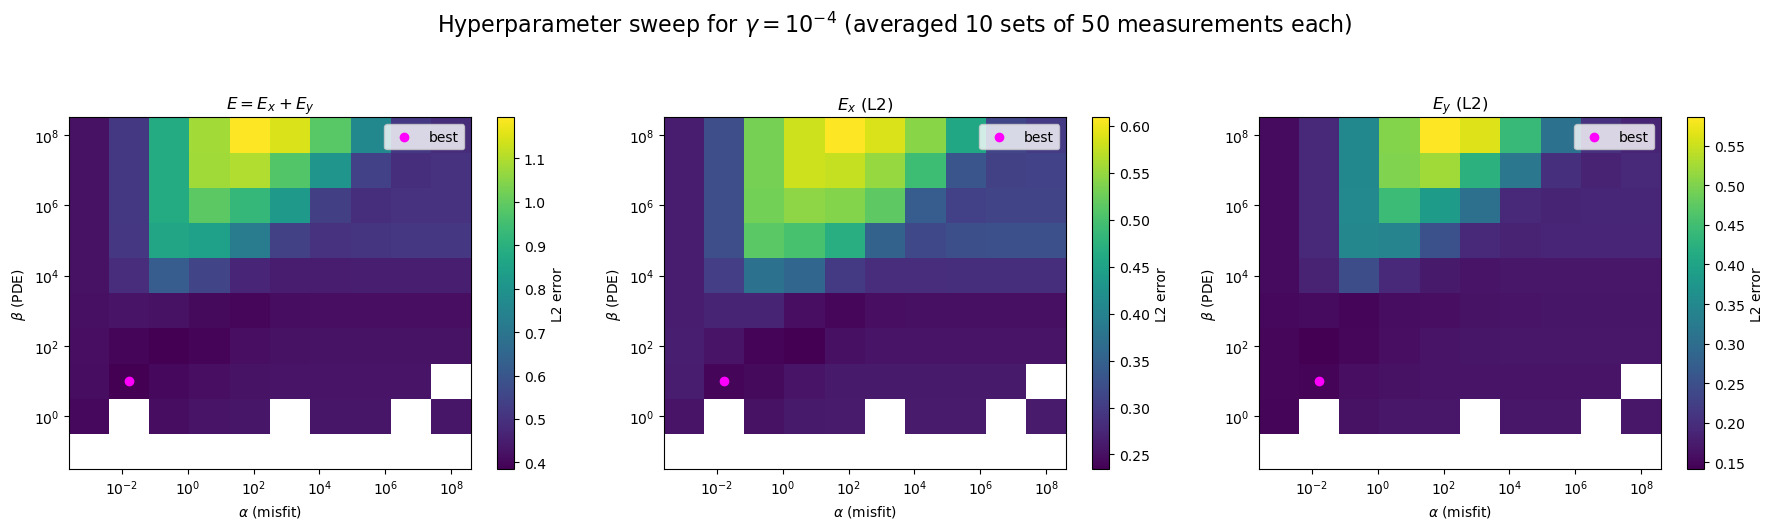

In [13]:
# Set ranges
alphas = np.logspace(-3, 8, 10)
betas  = np.logspace(-1, 8, 10)
gamma  = 1e-4


A, B, EM, ExM, EyM, best = tune_alpha_beta_avg(
    alphas=alphas, betas=betas, gamma_fixed=gamma,
    seeds=range(1, 11), 
    solve_kwargs=dict(maxit=3, tol=1e-4)
)

plot_tuning(A, B, EM, ExM, EyM, best, title=r"Hyperparameter sweep for $\gamma = 10^{-4}$ (averaged 10 sets of 50 measurements each)")


=== Running seed 1 ===

=== Running seed 2 ===

=== Running seed 3 ===

=== Running seed 4 ===

=== Running seed 5 ===

=== Running seed 6 ===

=== Running seed 7 ===

=== Running seed 8 ===

=== Running seed 9 ===

=== Running seed 10 ===


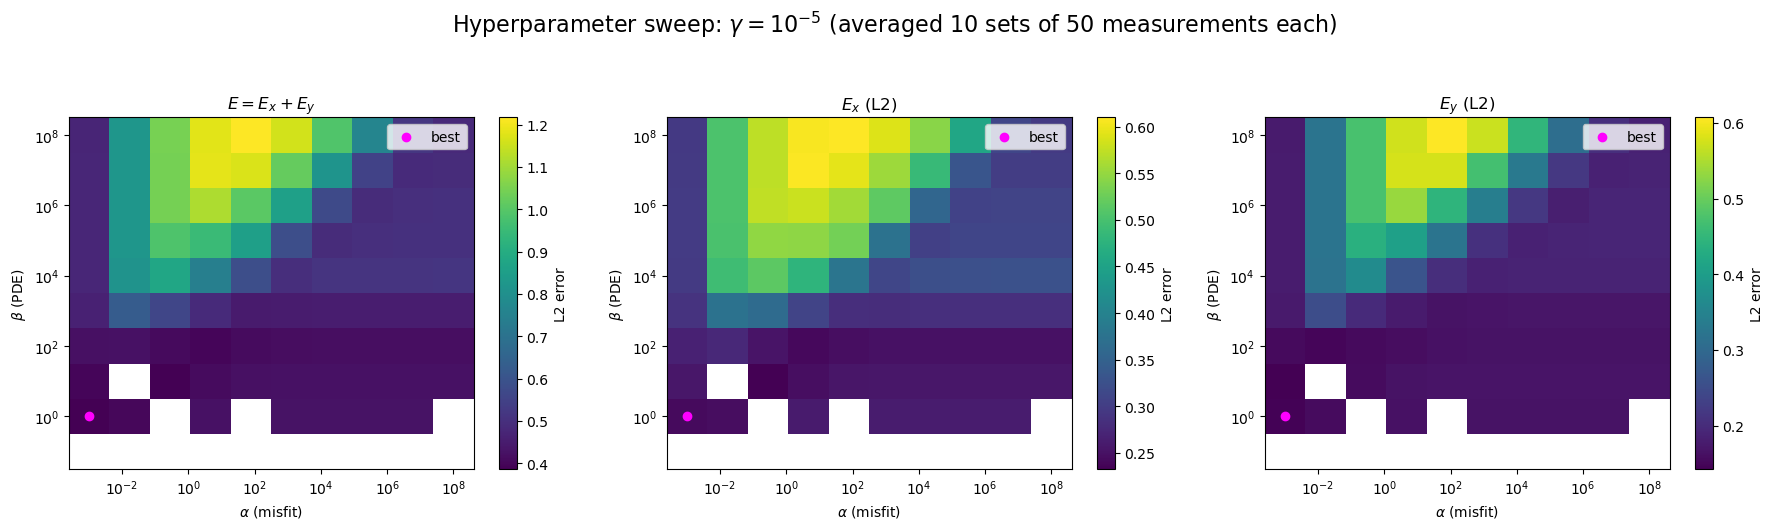

In [14]:
# Set ranges
alphas = np.logspace(-3, 8, 10)
betas  = np.logspace(-1, 8, 10)
gamma  = 1e-5


A, B, EM, ExM, EyM, best = tune_alpha_beta_avg(
    alphas=alphas, betas=betas, gamma_fixed=gamma,
    seeds=range(1, 11), 
    solve_kwargs=dict(maxit=3, tol=1e-4)
)

plot_tuning(A, B, EM, ExM, EyM, best, title=r"Hyperparameter sweep: $\gamma = 10^{-5}$ (averaged 10 sets of 50 measurements each)")